# Box Model - flopy

## Model Description 
This intially constructs the 2D (heterogeneous) steady state box model that you built for your BoxModel_Manual assignment

#### Dimensions: 
- 25 by 25 by 1
- dx = dy = 100 m
- dz = 10 m  

#### Subsurface Properties: 
- Heterogeneous 
- K = 1.0 m/day in x, y and z with a 5x5 inclusion with K = 0.1 m/day centered in the domain.  Inclusion is 5x5 cells.
- Porosity = 0.35
- Specific yield = 0.3
- Storage coefficient=0.001  

#### Boundary Conditions: 
 - Right boundary is constant head of 10 m relative to the datum, which is located at the bottom of the domain.  
 - Left boundary is a constant head of 20 m relative to the datum, which is located at the bottom of the domain.


## 1. Setup the environment

In [1]:
#the basics
import flopy
import numpy as np
import matplotlib as mp
import os

#additional analysis tools
import flopy.utils.binaryfile as bf
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
import csv

#jupyter specific--included to show plots in notebook
%matplotlib inline 

#Supress depricaiton warmnings
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# If you want to calculate the harmonic mean in python you need to conda install scipy 
# and uncomment this line
from scipy.stats import hmean

## 2. Create the model object

In [44]:
modelname = "WildcatFarms_Model_20260203"

m = flopy.modflow.Modflow(
    modelname,
    exe_name=r"C:\Users\guybw\OneDrive\Desktop\Semester2\modflow\mf2005.exe"
)

In [3]:
#optional delete old run files
run = 'n'
if run == 'y':
    # file_extensions = ['.dis','.bas','.lpf','.oc','.pcg','.wel']
    file_extensions = ['.dis','.bas','.bcf','.oc','.pcg']
    for ext in file_extensions:
        os.remove(modelname + ext)

## 3. Setup the discretization (DIS package)

For more details on DIS package inputs refer to : https://flopy.readthedocs.io/en/3.3.2/source/flopy.modflow.mfdis.html 

#### 3.1 Spatial discretization

In [4]:
nrow = 35 #number of rows
ncol = 35 #number of columns
nlay = 1  #number of layers

dx= 100 #width of grid cells in x direction 
dy= 100 #width of grid cells in y direction 

Lx = ncol*dx  #width of domain in x
Ly = nrow*dy #width of domain in y
ztop = 500.    #top elevation 
zbot = 0.     #bottom elevation

dz = (ztop - zbot) / nlay #cell height in z direction




In [5]:
import matplotlib.pyplot as plt

#### 3.2 Temporal discretization 

In [6]:
nper = 1 #number of stress periods 
steady = [True] #list noting the stress period type

#### 3.3 Create DIS object

In [7]:
#create flopy discretization object, length and time are meters (2) and days (4)
dis = flopy.modflow.ModflowDis(model=m, nlay=nlay, nrow=nrow, ncol=ncol, 
                               delr=dx, delc=dy, top=ztop, botm=zbot, 
                               itmuni = 4, lenuni = 2, 
                               nper=nper, steady=steady)

#### 3.4 Plot the grid

For help on this function see: https://flopy.readthedocs.io/en/3.3.2/source/flopy.plot.plotutil.html

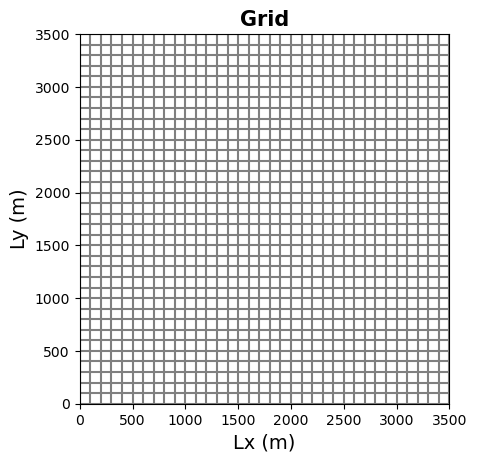

In [8]:
#use flopy to plot the grid of model 'm'
modelmap = flopy.plot.PlotMapView(model=m, layer=0)
grid = modelmap.plot_grid() 
plt.xlabel('Lx (m)',fontsize = 14)
plt.ylabel('Ly (m)',fontsize = 14)
plt.title('Grid', fontsize = 15, fontweight = 'bold')
plt.show()

## 4. Setup constant head boundaries, active cells and initial heads (BAS Package)

For more details on the BAS package see: https://flopy.readthedocs.io/en/3.3.2/source/flopy.modflow.mfbas.html

#### 4.1 Define cell activity: IBOUND 

In [9]:
#create ibound as array of ints = 1
ibound = np.ones((nlay, nrow, ncol), dtype=np.int32) #integer array of dim (z,y,x), makes all cells active     

#set constant head boundary on the left
ibound[:,:,0] = -1          #replace leftmost column (all zs, all ys, first x) with -1 to indicate constant head 
ibound[:,:,-1] = -1          #replace leftmost column (all zs, all ys, first x) with -1 to indicate constant head 

#print("ibound values: \n", ibound)

#### 4.2 Define starting heads 

In [9]:
#setup initial heads as 1 everywhere and 7 on the left boundary 
#H_init = np.ones((nlay, nrow, ncol), dtype=np.float32)  #float array (i.e. decimal), sets all heads to 1.0
#H_init[:, :, 0] = 497    #replace first (left) col with desired head value
#H_init[:, :, -1] = 445    #replace first (left) col with desired head value

#print("starting head values: \n", H_init)

Set up Head gradients across the grid

In [10]:
# --- Build interpolated head field from wells ---

from scipy.interpolate import griddata

# Well coordinates (top-left origin)
x_w = np.array([150, 150, 3450, 3450, 556.0, 500.0, 2852.0, 3000.0])
y_w = np.array([3500, 0, 3500, 0, 620, 2976, 688, 2978])
h_w = np.array([498, 498, 446, 445, 495.2, 494.6, 449.8, 448.4])

# Grid geometry
dx = dy = 100.0
nrow, ncol = 35, 35
Ly = nrow * dy

# Convert well Y to MODFLOW coordinates (top-left origin)
y_mod = Ly - y_w

# Cell centers
x_centers = (np.arange(ncol) + 0.5) * dx
y_centers = (np.arange(nrow) + 0.5) * dy
Xc, Yc = np.meshgrid(x_centers, y_centers)

# Interpolate
points = np.column_stack((x_w, y_w))
h_interp = griddata(points, h_w, (Xc, Yc), method='linear')

# Fill NaNs with nearest neighbor
h_interp_nn = griddata(points, h_w, (Xc, Yc), method='nearest')
mask = np.isnan(h_interp)
h_interp[mask] = h_interp_nn[mask]

# --- Apply constant head boundaries ---
H_init = h_interp.copy()
H_init[:, 0]  = 498.0   # west boundary
H_init[:, -1] = 445.0   # east boundary

# Reshape for MODFLOW
H_init = H_init.reshape((1, nrow, ncol))


#### 4.3 Create BAS object

In [11]:
#create flopy bas object
bas = flopy.modflow.ModflowBas(m, ibound=ibound, strt=H_init)

#### 4.4 Plot the grid and ibound

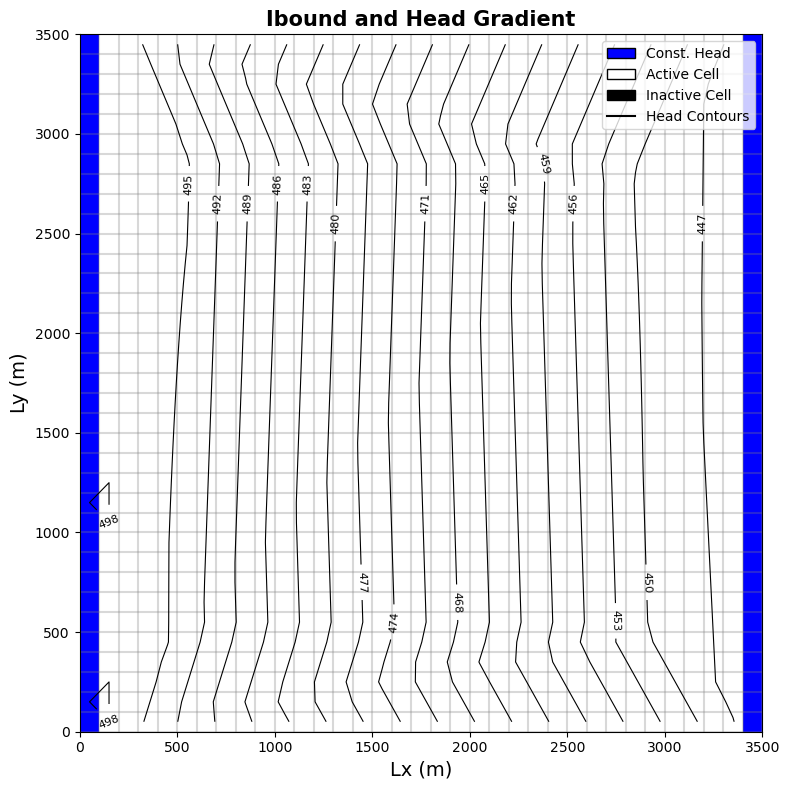

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))

modelmap = flopy.plot.PlotMapView(model=m, layer=0, ax=ax)

# Plot grid
modelmap.plot_grid(alpha=0.3)

# Plot ibound (constant-head cells will show in blue)
ib = modelmap.plot_ibound()

# Plot head contours (from your starting head array or results)
# If you haven't run the model yet, this will plot the starting heads (strt)
contours = modelmap.contour_array(H_init[0, :, :], 
                                  levels=20, 
                                  colors='k', 
                                  linewidths=0.8)

# Optional: add contour labels
plt.clabel(contours, inline=True, fontsize=8)

# Labels and title
plt.xlabel('Lx (m)', fontsize=14)
plt.ylabel('Ly (m)', fontsize=14)
plt.title('Ibound and Head Gradient', fontsize=15, fontweight='bold')

# Legend
legend_elements = [
    mp.patches.Patch(facecolor='blue', edgecolor='black', label='Const. Head'),
    mp.patches.Patch(facecolor='white', edgecolor='black', label='Active Cell'),
    mp.patches.Patch(facecolor='black', edgecolor='black', label='Inactive Cell'),
    mp.lines.Line2D([], [], color='k', label='Head Contours')
]

plt.legend(handles=legend_elements, bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
plt.show()

## 5. Setup Layer Properties  (LPF Package)

For more details on LPF package see: https://flopy.readthedocs.io/en/3.3.2/source/flopy.modflow.mflpf.html

#### 5.1 Set layer properties

In [13]:
from scipy.interpolate import Rbf

# Pilot point coordinates and K values
x_p = np.array([556.0, 500.0, 2852.0, 3000.0])
y_p = np.array([620, 2976, 688, 2978])
k_p = np.array([1.5, 13.0, 1.0, 8.4])

# Build grid of cell centers
dx = dy = 100.0
x_centers = (np.arange(ncol) + 0.5) * dx
y_centers = (np.arange(nrow) + 0.5) * dy
Xc, Yc = np.meshgrid(x_centers, y_centers)

# --- log(K) interpolation ---
log_k_p = np.log10(k_p)

rbf = Rbf(x_p, y_p, log_k_p, function='multiquadric', smooth=0)

logK_field = rbf(Xc, Yc)
K_field = 10**logK_field

# Max/min K values to avoid extreme values from interpolation
K_field = np.maximum(K_field, 1.0)    # minimum K = 1
K_field = np.minimum(K_field, 13.0)   # maximum K = 13


In [14]:
lpf = flopy.modflow.ModflowLpf(
    m,
    hk=K_field.reshape((1, nrow, ncol)),
    vka=K_field.reshape((1, nrow, ncol)),
    ipakcb=53
)


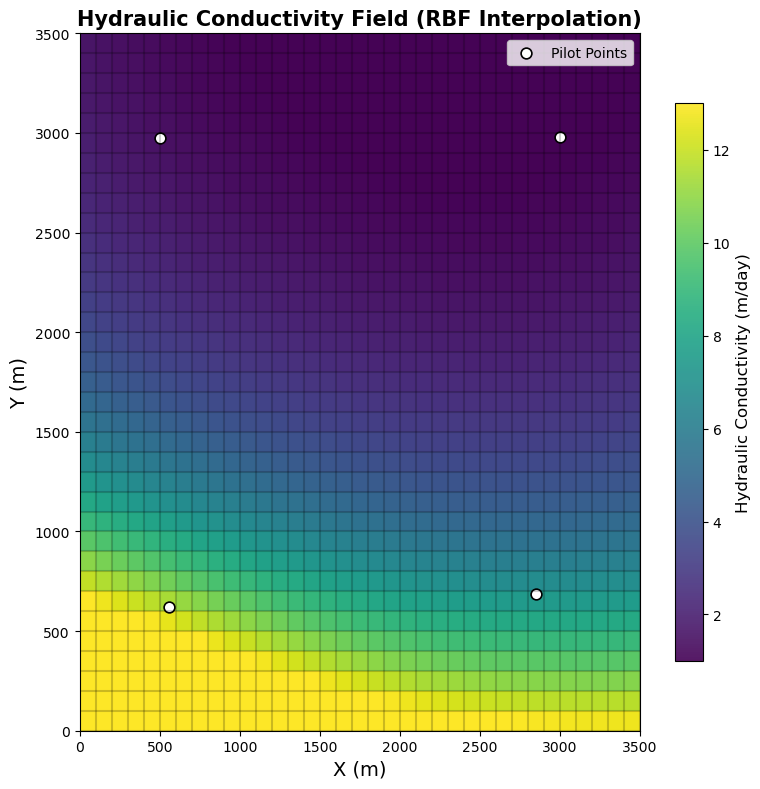

In [15]:
fig, ax = plt.subplots(figsize=(8, 8))

modelmap = flopy.plot.PlotMapView(model=m, layer=0, ax=ax)

# --- Plot K field using a color ramp ---
k_img = modelmap.plot_array(
    K_field,
    cmap='viridis',
    alpha=0.9
)

# Optional: overlay grid
modelmap.plot_grid(alpha=0.2, color='k')

# Optional: plot pilot points
ax.scatter(
    x_p, y_p,
    s=60,
    c='white',
    edgecolors='black',
    linewidths=1.2,
    label='Pilot Points'
)

# Colorbar
cbar = plt.colorbar(k_img, ax=ax, shrink=0.8)
cbar.set_label('Hydraulic Conductivity (m/day)', fontsize=12)

# Labels and title
plt.xlabel('X (m)', fontsize=14)
plt.ylabel('Y (m)', fontsize=14)
plt.title('Hydraulic Conductivity Field (RBF Interpolation)', fontsize=15, fontweight='bold')

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [16]:
K_horiz = K_field.copy()    #Setting Kx and Ky to the same field (isotropic)
K_vert = K_field.copy()     
n = 0.35        #assign porosity (arbitrary value for now, not used in steady-state)
Ss = 0.001      #assign storage coefficient
Sy = 0.3        #assign specific yield
uncnf = 1       #0=confined, >0 = unconfined

#### 5.2 Make LPF object

In [17]:
lpf = flopy.modflow.ModflowLpf(
    m,
    laytyp=1,          # unconfined
    hk=K_horiz,
    vka=K_vert,
    ss=Ss,
    sy=Sy,
    ipakcb=53
)



c:\Users\guybw\anaconda3\envs\hwrs564b\Lib\site-packages\flopy\mbase.py:623: UserWarning: Unit 15 of package LPF already in use.
  warn(
c:\Users\guybw\anaconda3\envs\hwrs564b\Lib\site-packages\flopy\mbase.py:632: UserWarning: Two packages of the same type, Replacing existing 'LPF' package.
  warn(


## 5b. Setup Cell-byCell Properties  (BCF Package)

For more details on LPF package see: https://flopy.readthedocs.io/en/3.3.2/source/flopy.modflow.mfbcf.html

Establish Farms within model domains

In [26]:
from shapely.geometry import Point, Polygon
import numpy as np

# -----------------------------
# 1. Define farm polygons (convert Y to top-left)
# -----------------------------
Ly = nrow * dy   # total model height

def bl_to_top(y):
    return Ly - y

# ACME polygon (SW, SE, NE, NW) 
acme_coords_bl = [
    (1200, 500),
    (2200, 500),
    (2200, 2500),
    (1200, 2500)
]

acme_poly = Polygon(acme_coords_bl)

# Wildcat polygon
wc_coords_bl = [
    (625, 2000),
    (973, 2000),
    (973, 2348),
    (625, 2348)
]

wc_poly = Polygon(wc_coords_bl)

# -----------------------------
# 2. Build grid of cell centers (top-left)
# -----------------------------
x_centers = (np.arange(ncol) + 0.5) * dx
y_centers_bl = (np.arange(nrow) + 0.5) * dy
y_centers = bl_to_top(y_centers_bl)

Xc, Yc = np.meshgrid(x_centers, y_centers)

# -----------------------------
# 3. Create masks
# -----------------------------
acme_mask = np.zeros((nrow, ncol), dtype=bool)
wc_mask   = np.zeros((nrow, ncol), dtype=bool)


for i in range(nrow):
    for j in range(ncol):
        pt = Point(Xc[i, j], Yc[i, j])
        if acme_poly.contains(pt):
            acme_mask[i, j] = True
        if wc_poly.contains(pt):
            wc_mask[i, j] = True

# -----------------------------
# 4. Build zone array
# -----------------------------
zones = np.zeros((nrow, ncol), dtype=int)
zones[acme_mask] = 1
zones[wc_mask]   = 2

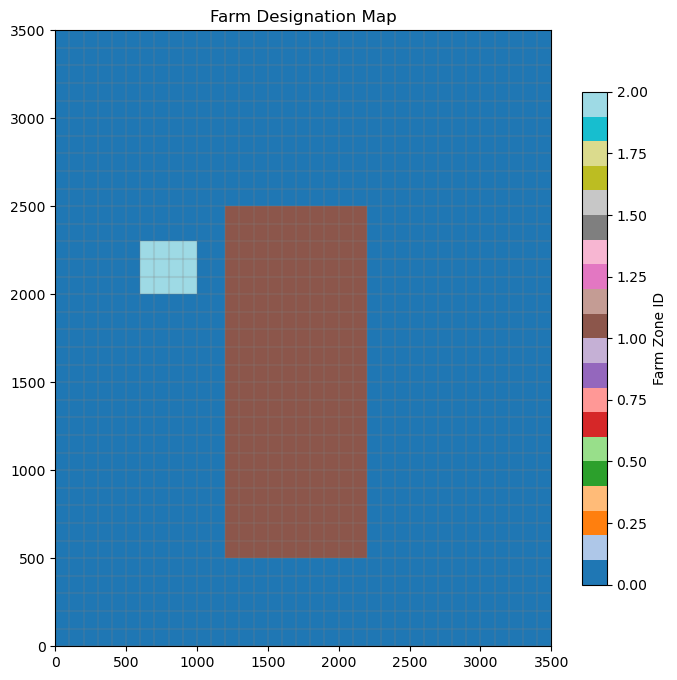

In [27]:
fig, ax = plt.subplots(figsize=(8, 8))
modelmap = flopy.plot.PlotMapView(model=m, layer=0, ax=ax)

zone_img = modelmap.plot_array(zones, cmap='tab20')
modelmap.plot_grid(alpha=0.2)

cbar = plt.colorbar(zone_img, ax=ax, shrink=0.8)
cbar.set_label('Farm Zone ID')

plt.title('Farm Designation Map')
plt.show()




#### 5b.1 Set cell properties pertaining to Fluxes in and out

In [28]:
# Recharge rate for non-farm areas
rch_rate = 1e-4  # m/day

# Initialize recharge array
rch_array = np.zeros((nrow, ncol), dtype=float)

# Apply recharge only where zones == 0 (non-farm)
rch_array[zones == 0] = rch_rate

# Add RCH package
rch = flopy.modflow.ModflowRch(
    m,
    rech=rch_array,
    nrchop=1,      # apply recharge to top layer
    ipakcb=53
)

print("Total recharge (m³/year):", np.sum(rch_array) * dx * dy * 365)

Total recharge (m³/year): 369745.00000000006


#Add Wells

In [29]:
# --- Pumping rates (m3/day) ---
Q_wc = -127048.9509 / 365.0
Q_acme = -1909328.782 / 365.0

# --- Compute well coordinates from polygons ---
# Wildcat center
minx, miny, maxx, maxy = wc_poly.bounds
wc_center = ((minx + maxx)/2, (miny + maxy)/2)

# ACME upper and lower halves
minx, miny, maxx, maxy = acme_poly.bounds
acme_mid_y = (miny + maxy) / 2

acme_lower_center = ((minx + maxx)/2, (miny + acme_mid_y)/2)
acme_upper_center = ((minx + maxx)/2, (acme_mid_y + maxy)/2)

# --- Convert (x,y) to (i,j) ---
def xy_to_ij(x, y, dx, dy, nrow):
    j = int(x // dx)
    i = int(y // dy)
    return i, j

# --- Build stress period data ---
wel_spd = []

# Wildcat well
i, j = xy_to_ij(*wc_center, dx, dy, nrow)
wel_spd.append([0, i, j, Q_wc])

# ACME lower well
i, j = xy_to_ij(*acme_lower_center, dx, dy, nrow)
wel_spd.append([0, i, j, Q_acme])

# ACME upper well
i, j = xy_to_ij(*acme_upper_center, dx, dy, nrow)
wel_spd.append([0, i, j, Q_acme])

# --- Add WEL package ---
wel = flopy.modflow.ModflowWel(
    m,
    stress_period_data={0: wel_spd},
    ipakcb=53
)

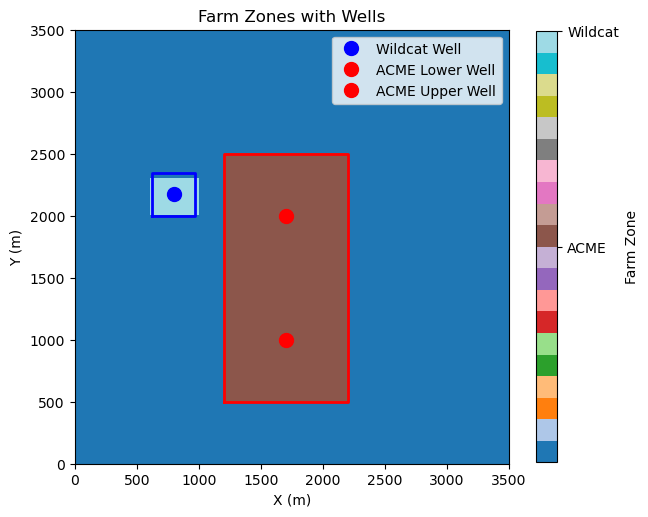

In [34]:
# --- Compute well coordinates again (for plotting) ---

# Wildcat center
minx, miny, maxx, maxy = wc_poly.bounds
wc_center = ((minx + maxx)/2, (miny + maxy)/2)

# ACME upper and lower halves
minx, miny, maxx, maxy = acme_poly.bounds
acme_mid_y = (miny + maxy) / 2

acme_lower_center = ((minx + maxx)/2, (miny + acme_mid_y)/2)
acme_upper_center = ((minx + maxx)/2, (acme_mid_y + maxy)/2)

# --- Plot farm zones with wells ---
Ly = nrow * dy

fig, ax = plt.subplots(figsize=(7, 7))

# Plot zones
im = ax.imshow(
    zones,
    origin='upper',
    extent=(0, Lx, 0, Ly),
    cmap='tab20'
)

# Colorbar with labels
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_ticks([1, 2])
cbar.set_ticklabels(['ACME', 'Wildcat'])
cbar.set_label('Farm Zone')

# Plot polygons
for poly, color in [(acme_poly, 'red'), (wc_poly, 'blue')]:
    x, y = poly.exterior.xy
    ax.plot(x, y, color=color, linewidth=2)

# Plot wells
ax.plot(wc_center[0], wc_center[1], 'bo', markersize=10, label='Wildcat Well')
ax.plot(acme_lower_center[0], acme_lower_center[1], 'ro', markersize=10, label='ACME Lower Well')
ax.plot(acme_upper_center[0], acme_upper_center[1], 'ro', markersize=10, label='ACME Upper Well')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('Farm Zones with Wells')
ax.legend()

plt.show()

#### 5b.2 Make BCF object

In [40]:
#assigns horizontal and vertical Ks and saves cell-by-cell budget data
bcf = flopy.modflow.ModflowBcf(m, ipakcb=53, intercellt=0, laycon=3, trpy=1.0, hdry=-1e+30, iwdflg=0, wetfct=0.1, iwetit=1, ihdwet=0, tran=1.0, hy=K_vals[0,:,:], vcont=1.0, sf1=Ss, sf2=Sy, wetdry=-0.01, extension='bcf', unitnumber=None, filenames=None) 


NameError: name 'K_vals' is not defined

## 6. Setup outputs by stress period (OC Package)
For more details on OC Package: https://flopy.readthedocs.io/en/3.3.2/source/flopy.modflow.mfoc.html

#### 6.1 Setup outputs

In [35]:
#create oc stress period data. 
#(0,0) tells OC package to save data for stress period 1, time step 1.
spd = {(0,0):['print head', 'print budget', 'save head', 'save budget']} #create a dictionary for stress period data, where key (0,0) is associated with value ['print...'] 

print("oc stress period data: \n", spd)

oc stress period data: 
 {(0, 0): ['print head', 'print budget', 'save head', 'save budget']}


#### 6.2 Make OC object 

In [36]:
oc = flopy.modflow.ModflowOc(model=m, stress_period_data=spd, compact=True)

## 7. Set the numerical solver (PCG Package)

We are using the Preconditioned Conjugate Gradient package:

Additionally, MODFLOW online describes these solvers: https://water.usgs.gov/ogw/modflow/MODFLOW-2005-Guide/index.html?oc.htm

And Flopy documents its communication with the PCG MODFLOW package: http://modflowpy.github.io/flopydoc/mfpcg.html

#### 7.1 Make the PCG object

In [37]:
pcg = flopy.modflow.ModflowPcg(model=m)

## 9. Write inputs and run the model 

#### 9.1 Write Inputs

In [38]:
m.write_input()    #uses the package objects created above to actually write the text files, 
                    #and saves to folder that this script is in
                    #after this step you should see the files appear in your folder


#### 9.2 Run the model

In [45]:
success, mfoutput = m.run_model(pause=False, report=True)

if not success:
    raise Exception("MODFLOW did not terminate normally.")

FloPy is using the following executable to run the model: ..\..\..\modflow\mf2005.exe


OSError: [WinError 216] This version of %1 is not compatible with the version of Windows you're running. Check your computer's system information and then contact the software publisher

## 10. Plot the results  

#### 10.1 Read in the model outputs

For information on binary files see: http://modflowpy.github.io/flopydoc/binaryfile.html 

For information on flow budget files see: 
http://modflowpy.github.io/flopydoc/binaryfile.html#flopy.utils.binaryfile.CellBudgetFile

##### Read the heads 

In [143]:
headobj = bf.HeadFile(modelname+'.hds')    #reads the binary head file
times = headobj.get_times()                #returns a list of timesteps
head = headobj.get_data(totim=times[-1])        #returns a numpy array of heads for specified time (last timestep)

#print('timesteps:', times)         
#print('final head:', 'dimensions', np.shape(head), '\n', head)    
#print('initial head:', 'dimensions', np.shape(H_init), '\n', H_init)
#print('well fluxes:', 'dimensions', np.shape(fluxes), '\n', fluxes)

##### Write Heads as csv

In [144]:
with open('FP_heads.csv', 'w', newline='') as csvfile:  #creates an empty csv file called FP_heads
    writer = csv.writer(csvfile, delimiter=',')        
    for i in range(len(head[0,:,0])):                    #writes each row
        writer.writerow(head[0,i,:])


##### Read the Water Balance and use it to find distribution of fluxes along boundary

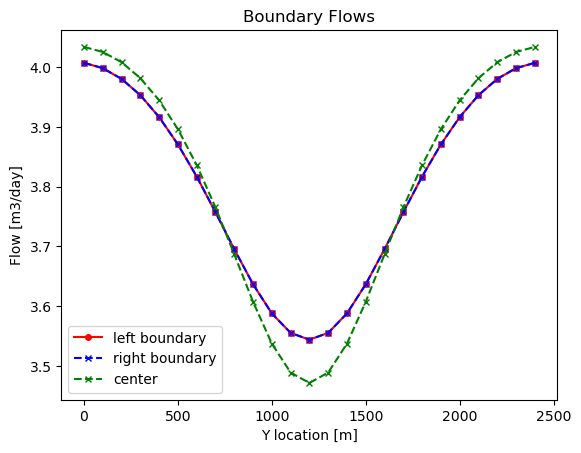

(25, 25)
3.9895704
4.0082154
[3.9803002 3.9895704 4.0082154 4.0363398 4.0738363 4.120039  4.1732802
 4.230436  4.2867336 4.3361826 4.3728204 4.3922467 4.3922467 4.3728204
 4.336182  4.2867336 4.230436  4.17328   4.120039  4.073836  4.0363398
 4.0082164 3.9895701 3.9803002 0.       ]


In [145]:
budgobj = bf.CellBudgetFile(modelname+'.cbc')   #reads the cell budget file    
kstpkper_list = budgobj.get_kstpkper()          #returns a list of stress periods & timesteps
frf = budgobj.get_data(text='flow right face', totim=1.0) #returns an array of flow rates for right face of cells
fff = budgobj.get_data(text='flow front face', totim=1.0) #returns an array of flow rates for front face of cells     
         #string options are in the list file under output control (make sure to include spaces!)

flux_vals=np.squeeze(frf)
leftflux = flux_vals[:,0]
rightflux = flux_vals[:,-2]
#centerflux = flux_vals[:,12]
centerflux = flux_vals[:,2]


bdryflux_fig = plt.figure() 
x=np.arange(0,ncol*dx,dx) 
plt.plot(x,leftflux,marker='o', color='red', markersize=4, linestyle='-',label="left boundary")
plt.plot(x,rightflux,marker='x', color='blue', markersize=4, linestyle='--',label="right boundary")
plt.plot(x,centerflux,marker='x', color='green', markersize=4, linestyle='--',label="center")
plt.xlabel('Y location [m]')
plt.ylabel('Flow [m3/day]')
plt.title("Boundary Flows")
plt.legend()
plt.show()

print(flux_vals.shape)
print(flux_vals[2,1])
print(flux_vals[2,2])
print(flux_vals[2,:])



### Calculate the total flux

In [146]:
#Calculate the total flux across the model
flux_tot  = np.sum(flux_vals[:, 0]) #total flux through one column of the model [m3/day]

# Calculate the equivalent K (q=k*A* dh/dl)
area = nrow *dy * (ztop-zbot)
dh_dl= (H_init[0,0,0]-H_init[0,0,-1])/Lx
#dh_dl = 10/2500
k_eff = flux_tot/area/dh_dl

# Calculate the arithmetic mean K
k_arr = np.mean(K_vals)

# Calcualte the harmonic mean K
k_harm = hmean(K_vals.flatten()) 

print("LowK", K_incl, "ArrMean", np.round(k_arr,2), "Hmean", np.round(k_harm,2), "Keff", np.round(k_eff,2), "Q", np.round(flux_tot,2) )


LowK 0.02 ArrMean 0.96 Hmean 0.34 Keff 0.95 Q 95.09


#### 10.2 Evaluate the head gradients

Head Gradient 0.004 m/m


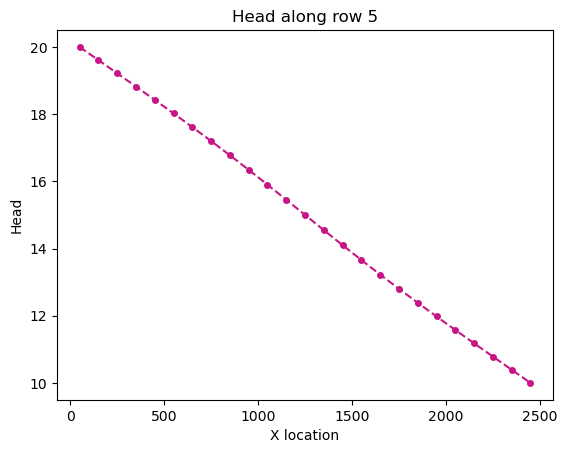

In [147]:
head_fig = plt.figure() 
#x=np.arange(100,2600,100) 
x=np.arange(dx/2,Lx,dx)
y=head[0,4,:]
plt.plot(x,y,marker='o', color='mediumvioletred', markersize=4, linestyle='--')
plt.xlabel('X location')
plt.ylabel('Head')
plt.title("Head along row 5")
#plt.axvline(x=1200)

#Save figure
# plt.savefig('Head_Transect.png') #save figure as a png

hgrad=(head[0,4,0]-head[0,4,-1])/Lx
print("Head Gradient", hgrad, "m/m") 

#### 10.3 3D plot of heads

Text(0.5, 0.92, 'Steady-State Model Head Profile')

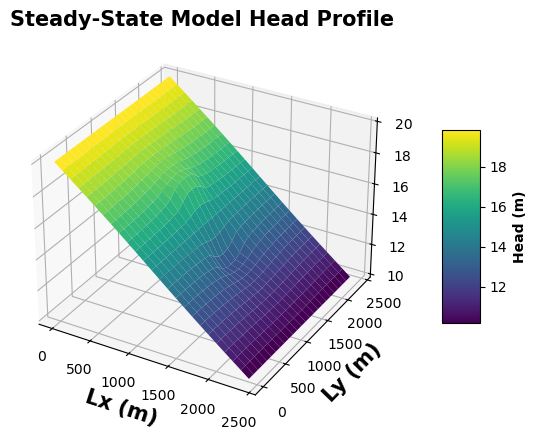

In [148]:
#create 3d figure
fig_3d = plt.figure(figsize=(12,5))
#ax = fig_3d.gca(projection='3d')
ax = fig_3d.add_subplot(111,projection='3d')

#set X, Y, Z variables for 3d plot to be our model domain and head solution
X = np.arange(0,Lx,dx)
Y = np.arange(0,Ly,dy)
X, Y = np.meshgrid(X, Y)
Z = np.flipud(head[0])

#create surface and labels
surf = ax.plot_surface(X,Y,Z, cmap = 'viridis', linewidth=0, label='head')
fig_3d.colorbar(surf,shrink=0.5,aspect=5).set_label('Head (m)',fontsize=10,fontweight='bold')
ax.set_xlabel('Lx (m)', fontsize=15, fontweight='bold')
ax.set_ylabel('Ly (m)', fontsize=15, fontweight='bold')
ax.set_title('Steady-State Model Head Profile', fontsize=15, fontweight='bold')
# plt.savefig('BoxModel_Surface1.png') 
#plt.show(surf)

### 10.4 Contour Head plot

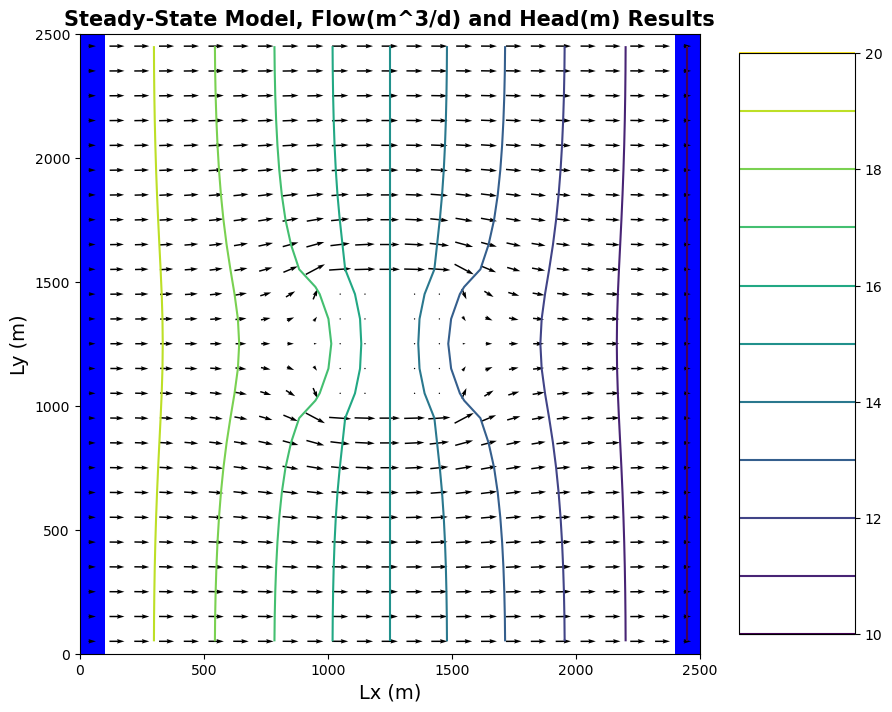

In [149]:
#Calculate the volumetric dischard (m3/day)
qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(
    (frf[0], fff[0], None), m) 

#plot first contour plot
fig1 = plt.figure(figsize=(10,10)) #create 10 x 10 figure
modelmap = flopy.plot.PlotMapView(model=m, layer=0) #use modelmap to attach plot to model
#grid = modelmap.plot_grid() #plot model grid
qm = modelmap.plot_ibound()  
contour_levels = np.linspace(head[0].min(),head[0].max(),11) #set contour levels for contouring head
head_contours = modelmap.contour_array(head, levels=contour_levels) #create head contours
quiver = modelmap.plot_vector(qx, qy)
#flows = modelmap.plot_discharge(frf[0], fff[0], head=head) #create discharge arrows

#display parameters
plt.xlabel('Lx (m)',fontsize = 14)
plt.ylabel('Ly (m)',fontsize = 14)
plt.title('Steady-State Model, Flow(m^3/d) and Head(m) Results', fontsize = 15, fontweight = 'bold')
plt.colorbar(head_contours,aspect=5)
# plt.savefig('BoxModel_vectors.png')   
#plt.show(modelmap)